In [1]:
import pandas as pd
import re
import openai
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, 
                             confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)
import pickle
import random
import tabulate
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import joblib
import seaborn as sns

/home/assif/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load dataset
df = pd.read_csv("/home/assif/Desktop/final/Training/ranked_responses_final.csv")

In [3]:
# Function to compute proportional rankings (converting ranks 1-4 into normalized scores)
def compute_proportional_ranks(ranks):
    rank_to_weight = {1: 4, 2: 3, 3: 2, 4: 1}
    total_weight = sum(rank_to_weight[r] for r in ranks)
    return [rank_to_weight[r] / total_weight for r in ranks]

In [4]:
# Later, when you want to load the embeddings without recomputing:
with open("df_processed.pkl", "rb") as f:
    df_processed = pickle.load(f)
print("Embeddings loaded from df_processed.pkl")

Embeddings loaded from df_processed.pkl


In [5]:
# === Fix: Map Source by removing duplicate prompts first ===
prompt_to_source = df[["Prompt", "Source"]].drop_duplicates().set_index("Prompt")["Source"]
df_processed["Source"] = df_processed["prompt"].map(prompt_to_source)

# === Drop rows with no source info ===
df_processed = df_processed.dropna(subset=["Source"])

# === Create category labels for stratification ===
category_labels = df_processed["Source"].astype("category").cat.codes

# === Prepare Features and Targets ===
X = np.vstack(df_processed["embedding"])
y = pd.DataFrame(df_processed["scores"].tolist(), columns=[
    "openai/gpt-4o", "anthropic/claude-3.5-sonnet", "deepseek/deepseek-chat", "perplexity/sonar"
])

# === Stratified Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=category_labels, random_state=42
)

In [8]:
# Progress context for joblib
class TqdmJoblib:
    def __init__(self, tqdm_object): self.tqdm_object = tqdm_object
    def __enter__(self):
        self.original_callback = joblib.parallel.BatchCompletionCallBack
        tqdm_obj = self.tqdm_object
        class TqdmBatchCompletionCallBack(self.original_callback):
            def __call__(self, *args, **kwargs):
                result = super().__call__(*args, **kwargs)
                tqdm_obj.update(n=self.batch_size)
                return result
        joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallBack
        return self
    def __exit__(self, exc_type, exc_val, exc_tb):
        joblib.parallel.BatchCompletionCallBack = self.original_callback

# Define model and hyperparameters
model = MultiOutputRegressor(
    XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        n_jobs=2,
        verbosity=0,
        eval_metric="rmse"
    ),
    n_jobs=4
)

param_grid = {
    "estimator__max_depth": [3, 5, 10],
    "estimator__learning_rate": [0.001, 0.01, 0.1],
    "estimator__n_estimators": [100, 200]
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=1,
    verbose=3,
    return_train_score=True
)

# Track total iterations
total_combinations = np.prod([len(v) for v in param_grid.values()])
total_iterations = total_combinations * 5

# Run training with progress bar
with TqdmJoblib(tqdm(total=total_iterations, desc="Grid Search Progress")):
    grid_search.fit(X_train, y_train)

# Best model
best_clf = grid_search.best_estimator_

Grid Search Progress:   0%|          | 0/90 [00:00<?, ?it/s]

Fitting 5 folds for each of 18 candidates, totalling 90 fits


Grid Search Progress:  10%|█         | 9/90 [00:09<00:31,  2.61it/s]

[CV 1/5] END estimator__learning_rate=0.001, estimator__max_depth=3, estimator__n_estimators=100;, score=(train=-0.010, test=-0.010) total time=   9.1s


Grid Search Progress:  23%|██▎       | 21/90 [00:17<00:22,  3.06it/s]

...

Grid Search Progress: 1068it [2:23:43,  3.54s/it]

[CV 4/5] END estimator__learning_rate=0.1, estimator__max_depth=10, estimator__n_estimators=200;, score=(train=-0.000, test=-0.008) total time= 3.0min


Grid Search Progress: 1077it [2:26:47,  6.76s/it]

[CV 5/5] END estimator__learning_rate=0.1, estimator__max_depth=10, estimator__n_estimators=200;, score=(train=-0.000, test=-0.008) total time= 3.1min


Grid Search Progress: 1083it [2:26:55,  3.47s/it]

In [11]:
import joblib

# Save to a file
joblib.dump(best_clf, 'best_xgb_model2.pkl')
print("Model saved as best_xgb_model2.pkl")

Model saved as best_xgb_model2.pkl


In [12]:
# Predict on the test set
y_pred = best_clf.predict(X_test)

# Regression evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nRegression Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")


Regression Evaluation Metrics:
Mean Squared Error (MSE): 0.0080
Mean Absolute Error (MAE): 0.0742
R² Score: 0.2092



Classification Evaluation Metrics:
Confusion Matrix:
[[583 249 159  67]
 [289 350 241 178]
 [140 279 372 267]
 [ 46 180 286 546]]
Accuracy: 0.4374
Precision: 0.4374
Recall: 0.4374
F1 Score: 0.4374


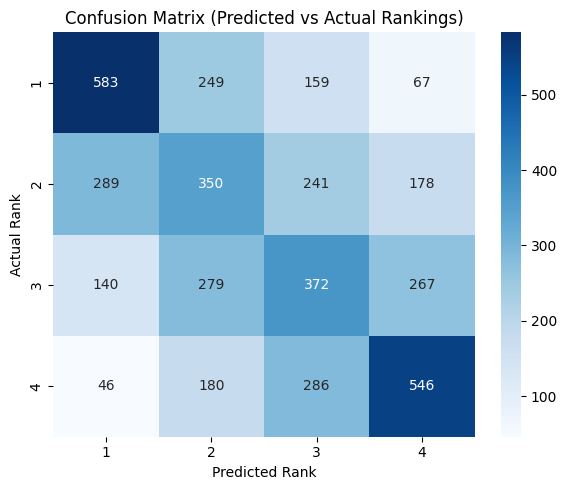

In [13]:
# Function to convert a dictionary of model scores into rankings (1 = best, 4 = worst)
def convert_to_ranking(scores):
    sorted_models = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return {model: rank + 1 for rank, (model, _) in enumerate(sorted_models)}

# Ensure consistent model order
model_names = list(y.columns)

# Convert actual and predicted scores to rankings per model
actual_ranks = []
predicted_ranks = []

for i in range(len(X_test)):
    actual_scores = dict(zip(model_names, y_test.iloc[i].values))
    predicted_scores = dict(zip(model_names, y_pred[i]))

    actual_ranking = convert_to_ranking(actual_scores)
    predicted_ranking = convert_to_ranking(predicted_scores)

    # Collect rankings per model (ensuring matching order)
    for model in model_names:
        actual_ranks.append(actual_ranking[model])
        predicted_ranks.append(predicted_ranking[model])

# Compute classification metrics
conf_mat = confusion_matrix(actual_ranks, predicted_ranks, labels=[1, 2, 3, 4])
acc_score = accuracy_score(actual_ranks, predicted_ranks)
precision_val = precision_score(actual_ranks, predicted_ranks, average='macro')
recall_val = recall_score(actual_ranks, predicted_ranks, average='macro')
f1_val = f1_score(actual_ranks, predicted_ranks, average='macro')

# Print metrics
print("\nClassification Evaluation Metrics:")
print("Confusion Matrix:")
print(conf_mat)
print(f"Accuracy: {acc_score:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall: {recall_val:.4f}")
print(f"F1 Score: {f1_val:.4f}")

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
plt.title("Confusion Matrix (Predicted vs Actual Rankings)")
plt.xlabel("Predicted Rank")
plt.ylabel("Actual Rank")
plt.tight_layout()
plt.show()

In [14]:
# For sample evaluation, map prompts to their IDs
id_mapping = df_processed.set_index("prompt").join(df.set_index("Prompt")[["ID"]]).reset_index()

# Select 4 random samples from the test set for detailed evaluation
sample_indices = random.sample(range(len(X_test)), 4)
sample_prompts = df_processed.iloc[sample_indices]["prompt"].tolist()
sample_actual = y_test.iloc[sample_indices].values
sample_predicted = y_pred[sample_indices]

# Format the sample evaluation data: convert actual and predicted scores into rankings
formatted_data = []
for i in range(4):
    prompt_text = sample_prompts[i]
    prompt_id = id_mapping[id_mapping["prompt"] == prompt_text]["ID"].values[0]

    actual_scores = {model: round(score, 2) for model, score in zip(y.columns, sample_actual[i])}
    predicted_scores = {model: round(score, 2) for model, score in zip(y.columns, sample_predicted[i])}
    
    actual_ranking = convert_to_ranking(actual_scores)
    predicted_ranking = convert_to_ranking(predicted_scores)
    
    formatted_data.append([
        prompt_id,
        actual_ranking["openai/gpt-4o"], predicted_ranking["openai/gpt-4o"],
        actual_ranking["anthropic/claude-3.5-sonnet"], predicted_ranking["anthropic/claude-3.5-sonnet"],
        actual_ranking["deepseek/deepseek-chat"], predicted_ranking["deepseek/deepseek-chat"],
        actual_ranking["perplexity/sonar"], predicted_ranking["perplexity/sonar"]
    ])

headers = [
    "ID", "OpenAI Act", "OpenAI Pred",
    "Claude Act", "Claude Pred",
    "DeepSeek Act", "DeepSeek Pred",
    "Perplex Act", "Perplex Pred"
]

print("\nRandom Sample Evaluation:")
print(tabulate.tabulate(formatted_data, headers=headers, tablefmt="fancy_grid"))

# Save sample evaluation results to a file
evaluation_file = "evaluation_output.txt"
with open(evaluation_file, "w", encoding="utf-8") as f:
    f.write(tabulate.tabulate(formatted_data, headers=headers, tablefmt="grid"))

print(f"\nEvaluation results saved to {evaluation_file}, download it to check.")


Random Sample Evaluation:
╒══════╤══════════════╤═══════════════╤══════════════╤═══════════════╤════════════════╤═════════════════╤═══════════════╤════════════════╕
│   ID │   OpenAI Act │   OpenAI Pred │   Claude Act │   Claude Pred │   DeepSeek Act │   DeepSeek Pred │   Perplex Act │   Perplex Pred │
╞══════╪══════════════╪═══════════════╪══════════════╪═══════════════╪════════════════╪═════════════════╪═══════════════╪════════════════╡
│  314 │            4 │             2 │            1 │             3 │              2 │               1 │             3 │              4 │
├──────┼──────────────┼───────────────┼──────────────┼───────────────┼────────────────┼─────────────────┼───────────────┼────────────────┤
│  846 │            3 │             3 │            4 │             2 │              1 │               1 │             2 │              4 │
├──────┼──────────────┼───────────────┼──────────────┼───────────────┼────────────────┼─────────────────┼───────────────┼────────────────┤



Evaluation for Predicting Best Model (Rank 1 Only):
Confusion Matrix:
[[  7  68 128   0]
 [  9 259 127   2]
 [  4  51 309  11]
 [  0   8  67   8]]
Accuracy: 0.5510
Precision: 0.4729
Recall: 0.4018
F1 Score: 0.3731


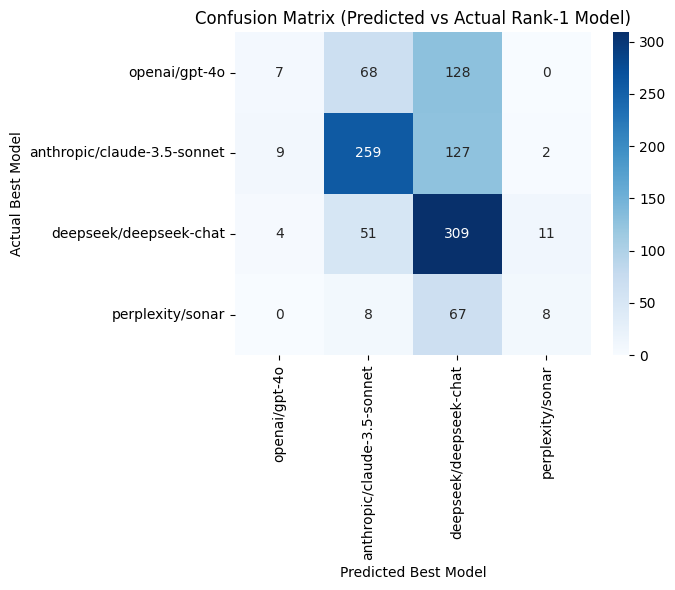

In [15]:
# Function to convert a dictionary of model scores into rankings (1 = best)
def convert_to_ranking(scores):
    sorted_models = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return {model: rank + 1 for rank, (model, _) in enumerate(sorted_models)}

# Get model names in consistent order
model_names = list(y.columns)

# Store only the model that got rank 1
actual_best_models = []
predicted_best_models = []

for i in range(len(X_test)):
    actual_scores = dict(zip(model_names, y_test.iloc[i].values))
    predicted_scores = dict(zip(model_names, y_pred[i]))

    actual_ranking = convert_to_ranking(actual_scores)
    predicted_ranking = convert_to_ranking(predicted_scores)

    # Get model name with rank 1
    actual_best = [model for model, rank in actual_ranking.items() if rank == 1][0]
    predicted_best = [model for model, rank in predicted_ranking.items() if rank == 1][0]

    actual_best_models.append(actual_best)
    predicted_best_models.append(predicted_best)

# Compute metrics treating model names as class labels
acc_score = accuracy_score(actual_best_models, predicted_best_models)
precision_val = precision_score(actual_best_models, predicted_best_models, average='macro')
recall_val = recall_score(actual_best_models, predicted_best_models, average='macro')
f1_val = f1_score(actual_best_models, predicted_best_models, average='macro')
conf_mat = confusion_matrix(actual_best_models, predicted_best_models, labels=model_names)

# Display
print("\nEvaluation for Predicting Best Model (Rank 1 Only):")
print("Confusion Matrix:")
print(conf_mat)
print(f"Accuracy: {acc_score:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall: {recall_val:.4f}")
print(f"F1 Score: {f1_val:.4f}")

# Confusion matrix heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=model_names, yticklabels=model_names)
plt.title("Confusion Matrix (Predicted vs Actual Rank-1 Model)")
plt.xlabel("Predicted Best Model")
plt.ylabel("Actual Best Model")
plt.tight_layout()
plt.show()

In [6]:
import joblib
import numpy as np
import pandas as pd

# Load the saved XGBoost ensemble model
best_clf = joblib.load('best_xgb_model2.pkl')

# Assuming X_test and y_test are already defined from your previous code:
# X_test: numpy array of test set features
# y_test: DataFrame with columns corresponding to each LLM's scores

# Run predictions on the test set
y_pred = best_clf.predict(X_test)

# Function to convert scores into a ranking dictionary (1 = best, 4 = worst)
def convert_to_ranking(scores):
    # Sort models by their score (highest score gets rank 1)
    sorted_models = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return {model: rank + 1 for rank, (model, _) in enumerate(sorted_models)}

# Get the model names (assumed to be the same as the columns in y_test)
model_names = list(y_test.columns)

# Initialize a dictionary to accumulate points for each LLM
llm_points = {model: 0 for model in model_names}
total_examples = len(X_test)

# Loop over each test example
for i in range(total_examples):
    # Get ground truth scores for the current example
    true_scores = dict(zip(model_names, y_test.iloc[i].values))
    # Get predicted scores from the ensemble model
    pred_scores = dict(zip(model_names, y_pred[i]))
    
    # Compute rankings for the ground truth and predicted scores
    true_ranking = convert_to_ranking(true_scores)
    ensemble_ranking = convert_to_ranking(pred_scores)
    
    # Determine the ensemble's best predicted model (the one ranked 1)
    ensemble_best = [model for model, rank in ensemble_ranking.items() if rank == 1][0]
    
    # For each LLM, compare the ensemble's prediction against the ground truth ranking:
    for llm in model_names:
        if ensemble_best == llm:
            # Tie: ensemble picked the same model as the LLM → 0.5 points
            points = 0.5
        else:
            # If the ensemble's best model is ranked higher (lower rank number) than the LLM, assign 1 point.
            points = 1 if true_ranking[ensemble_best] < true_ranking[llm] else 0
        llm_points[llm] += points

# Compute win rates as a percentage for each LLM
win_rates = {llm: (points / total_examples) * 100 for llm, points in llm_points.items()}

# Display the win rates
print("Win Rates for each LLM (comparing XGBoost ensemble prediction to ground truth):")
for llm, rate in win_rates.items():
    print(f"{llm}: {rate:.2f}%")

Win Rates for each LLM (comparing XGBoost ensemble prediction to ground truth):
openai/gpt-4o: 72.21%
anthropic/claude-3.5-sonnet: 63.04%
deepseek/deepseek-chat: 61.67%
perplexity/sonar: 86.25%
